<a href="https://www.kaggle.com/code/skailshvenkat/fem-fdm?scriptVersionId=229189092" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image  

dataset_path = '/kaggle/input/normal/NORMAL' 
image_size = (128, 128)  

def load_images(dataset_path, image_size=(128, 128)):
    images = []
    img_names = sorted(os.listdir(dataset_path))  # Sort to maintain order
    for img_name in img_names:
        img_path = os.path.join(dataset_path, img_name)
        img = image.load_img(img_path, target_size=image_size)  
        img = image.img_to_array(img)  
        img = img / 255.0  
        images.append(img)
    return np.array(images)

images = load_images(dataset_path)

X_train = images[:1008]   
X_val = images[1008:1323] 
X_test = images[1323:1575] 

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (1008, 128, 128, 3)
X_val shape: (315, 128, 128, 3)
X_test shape: (252, 128, 128, 3)


In [3]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_complex_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Flatten()(x)
    latent = layers.Dense(256, activation="relu")(x)

    return models.Model(inputs, latent, name="Complex_Encoder")



In [4]:
def build_complex_decoder(latent_dim=256, target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(16 * 16 * 128, activation="relu")(inputs)
    x = layers.Reshape((16, 16, 128))(x)

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x
                                   )
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Complex_Decoder")



In [5]:

import tensorflow.keras.backend as K

In [6]:
from skimage.metrics import structural_similarity as ssim

In [7]:

def combined_loss(y_true, y_pred):
    mse_loss = K.mean(K.square(y_true - y_pred))
    ssim_loss = K.mean(1 - tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.99 * mse_loss + 0.01 * ssim_loss

def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_complex_encoder(input_shape)
    decoder = build_complex_decoder(latent_dim=256, target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    latent = encoder(inputs)
    reconstructed = decoder(latent)

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss=combined_loss)
    return autoencoder

In [8]:
import tensorflow as tf

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Complex_Encoder (Functional)         │ (None, 256)                 │       8,853,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Complex_Decoder (Functional)         │ (None, 128, 128, 3)         │       9,033,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,887,107 (68.23 MB)

 Trainable params: 17,884,675 (68.22 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 121ms/step - loss: 0.0471 - val_loss: 0.0549
Epoch 2/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0200 - val_loss: 0.0602
Epoch 3/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0161 - val_loss: 0.0716
Epoch 4/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0143 - val_loss: 0.0504
Epoch 5/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0130 - val_loss: 0.0358
Epoch 6/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0122 - val_loss: 0.0219
Epoch 7/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0117 - val_loss: 0.0179
Epoch 8/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0110 - val_loss: 0.0142
Epoch 9/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0107 - val_loss: 0.0129
Epoch 10/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0107 - val_loss: 0.0124
Epoch 11/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0100 - val_loss: 0.0125
Epoch 12/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0

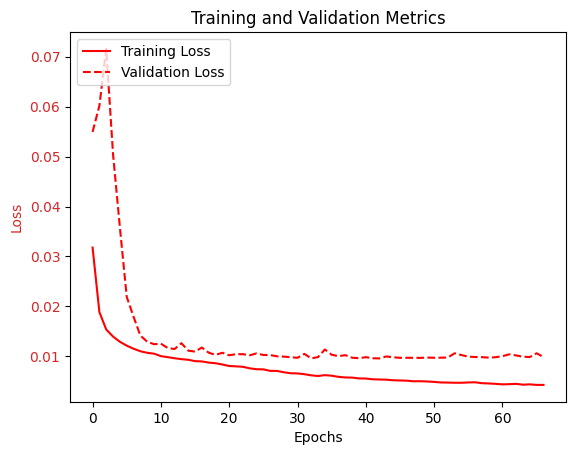

In [9]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import History

autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

start_time = time.time()

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=67,
    batch_size=16,
    callbacks=[History()]  
)

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

fig, ax1 = plt.subplots()

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(history.epoch, history.history['loss'], 'r-', label='Training Loss')
ax1.plot(history.epoch, history.history['val_loss'], 'r--', label='Validation Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')

plt.title("Training and Validation Metrics")
plt.show()

In [10]:
from skimage.metrics import structural_similarity as ssim

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Testing time for image 1: 1.79457 sec, SSIM: 0.99340
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Testing time for image 2: 0.06231 sec, SSIM: 0.99523
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Testing time for image 3: 0.05026 sec, SSIM: 0.99579
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Testing time for image 4: 0.05485 sec, SSIM: 0.99627
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Testing time for image 5: 0.05381 sec, SSIM: 0.99644
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Testing time for image 6: 0.05005 sec, SSIM: 0.99554
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Testing time for image 7: 0.05110 sec, SSIM: 0.99405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Testing time for image 8: 0.04999 sec, SSIM: 0.99560
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Testing time for image 9: 0.05123 sec, SSIM: 0.99430
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Testing time for image 10: 0.05432 sec, SSIM: 0.99526
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Testing time for image 11: 0.05082 sec, SSIM: 0.99575

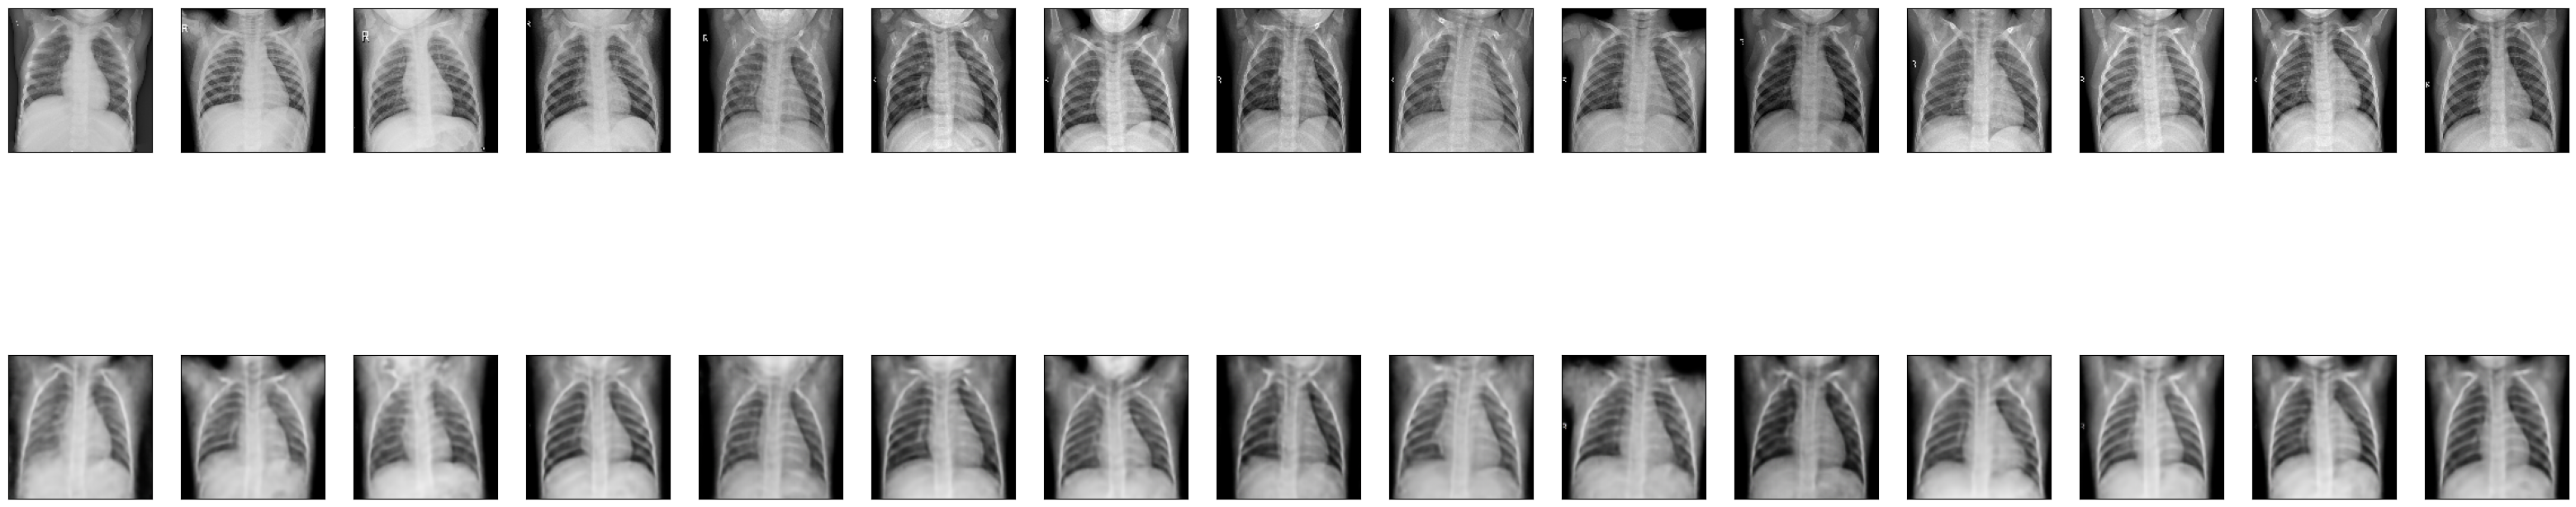

In [11]:
import numpy as np
import time
import matplotlib.pyplot as plt

def calculate_mse(image1, image2):
    return np.mean((image1 - image2) ** 2)

testing_times = []
decoded_imgs = []
ssim_values = []

for i in range(len(X_test)):
    test_start_time = time.time()
    decoded_img = autoencoder.predict(X_test[i:i+1])  
    test_end_time = time.time()
    
    testing_time = test_end_time - test_start_time
    testing_times.append(testing_time)
    decoded_imgs.append(decoded_img[0])
    x = calculate_mse(X_test[i], decoded_img[0])
    

    ssim_value = 1 - x
    ssim_values.append(ssim_value)
    
    print(f"Testing time for image {i+1}: {testing_time:.5f} sec, SSIM: {ssim_value:.5f}")

total_testing_time = sum(testing_times)
average_testing_time = total_testing_time / len(X_test)
total_ssim=sum(ssim_values)
avg_ssim=total_ssim / len(ssim_values)
print(f"Total testing time: {total_testing_time:.2f} seconds")
print(f"Average testing time per image: {average_testing_time:.5f} seconds")

print(f"Total testing time: {total_testing_time:.2f} seconds")
print(f"Average testing time per image: {average_testing_time:.5f} seconds")

print(f"Average SSIM per image: {(avg_ssim*100):.5f}%")

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [12]:
import pandas as pd

df = pd.DataFrame({
    "Image_No": list(range(1, len(X_test) + 1)),
    "SSIM_Value": ssim_values,
    "Time_Taken": testing_times
})

csv_filename = "ssim_results.csv"
df.to_csv(csv_filename, index=False)

from IPython.display import FileLink
FileLink(csv_filename)


/kaggle/working/ssim_results.csv

In [15]:
# Extract and save the encoder model
encoder = autoencoder.get_layer("Complex_Encoder")  # Use the correct layer name
encoder.save("encoder_model.h5")


In [ ]:
decoded_imgs = autoencoder.predict(X_train)

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_train[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [ ]:
encoder = autoencoder.get_layer("Complex_Encoder")
encoder.summary() 

In [ ]:
decoder = autoencoder.get_layer("Complex_Decoder")
decoder.summary() 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Model


layer_name = "batch_normalization"  
# Create a model that outputs the activations of the batch norm layer
intermediate_model = Model(inputs=encoder.input, outputs=encoder.get_layer(layer_name).output)

# Extract gamma and beta values
bn_layer = encoder.get_layer(layer_name)
gamma, beta = bn_layer.get_weights()[0], bn_layer.get_weights()[1]

# Define the number of batches to process
num_batches = 10
batch_size = 16

mean_list = []
var_list = []

for i in range(num_batches):
    sample_batch = X_train[i * batch_size : (i + 1) * batch_size]  # Extract batch
    activations = intermediate_model.predict(sample_batch)

    # Compute mean and variance
    mean_values = np.mean(activations, axis=(0, 1, 2))
    var_values = np.var(activations, axis=(0, 1, 2))

    mean_list.extend(mean_values)
    var_list.extend(var_values)

# Convert lists to numpy arrays
mean_list = np.array(mean_list)
var_list = np.array(var_list)

# Plot mean distribution
plt.figure(figsize=(8, 5))
plt.hist(mean_list, bins=50, color='b', alpha=0.7)
plt.axvline(0, color='r', linestyle="--", label="Expected Mean (0)")
plt.title("Mean of Batch Normalization Output Across Batches")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.xlim(-0.1,0.2)
plt.legend()
plt.show()

# Plot variance distribution
plt.figure(figsize=(8, 5))
plt.hist(var_list, bins=50, color='g', alpha=0.7)
plt.axvline(1, color='r', linestyle="--", label="Expected Variance (1)")
plt.title("Variance of Batch Normalization Output Across Batches")
plt.xlabel("Variance Value")
plt.ylabel("Frequency")
plt.xlim(0.2,1.2)
plt.legend()
plt.show()

# Print mean and variance ranges
print(f"Mean range: {mean_list.min()} to {mean_list.max()}")
print(f"Variance range: {var_list.min()} to {var_list.max()}")

# Print gamma and beta values
print("\nGamma (Scale) values:")
print(gamma)

print("\nBeta (Shift) values:")
print(beta)


In [ ]:
from keras.models import Model

conv_layer_name = "activation"
feature_map_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps)))  

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


In [ ]:
from keras.models import Model

conv_layer_name = "activation_1"
feature_map_model1 = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model1.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  # Expected: (1, 16, 16, 128)

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


In [ ]:
import numpy as np
from tensorflow.keras.models import Model

conv_layer_name = "dense"
latent_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

latent_vectors = latent_model.predict(X_test[:10])

for i, vector in enumerate(latent_vectors):
    print(f"Latent vector for test image {i + 1}:")
    print(vector)
    print("-" * 50)


In [ ]:
decoder = autoencoder.get_layer("Complex_Decoder")
decoder.summary() 

In [ ]:
latent_vectors.shape

In [ ]:
encoder = autoencoder.get_layer("Complex_Encoder")  
decoder = autoencoder.get_layer("Complex_Decoder")  

encoded_data = encoder.predict(X_test)

y_test = decoder.predict(encoded_data)

n = 15 
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(y_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
encoded_data.shape

In [16]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    # No Flatten, keeping feature maps
    return models.Model(inputs, x, name="Encoder")

def build_decoder(target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(16, 16, 128))  # Assuming feature maps size here

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Decoder")

In [17]:
def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_encoder(input_shape)
    decoder = build_decoder(target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    feature_maps = encoder(inputs)  # Outputs feature maps
    reconstructed = decoder(feature_maps)  # Decoder takes feature maps as input

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mean_squared_error")
    return autoencoder

autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

# Training the autoencoder
autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=67,
    batch_size=16,
) 


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder (Functional)                 │ (None, 16, 16, 128)         │         464,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder (Functional)                 │ (None, 128, 128, 3)         │         612,163 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,076,867 (4.11 MB)

 Trainable params: 1,074,435 (4.10 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - loss: 0.0280 - val_loss: 0.0642
Epoch 2/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0036 - val_loss: 0.0496
Epoch 3/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0028 - val_loss: 0.0369
Epoch 4/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0024 - val_loss: 0.0203
Epoch 5/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0025 - val_loss: 0.0110
Epoch 6/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0022 - val_loss: 0.0032
Epoch 7/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0020 - val_loss: 0.0045
Epoch 8/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0019 - val_loss: 0.0040
Epoch 9/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0019 - val_loss: 0.0037
Epoch 10/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0018 - val_loss: 0.0032
Epoch 11/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 12/67
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


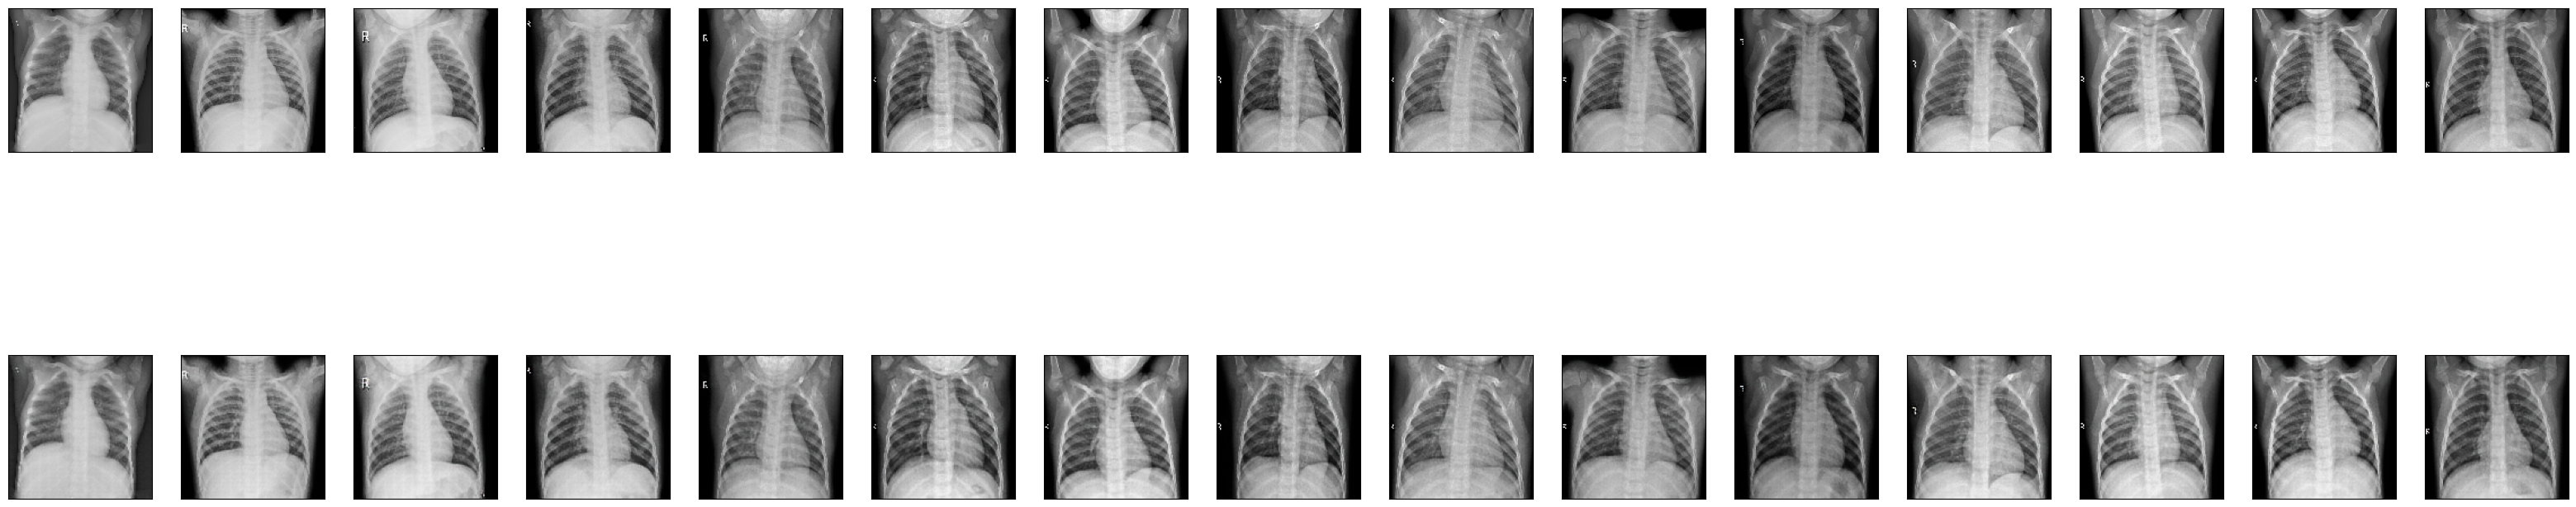

In [19]:

# Predicting decoded images
decoded_imgs = autoencoder.predict(X_test)

# Displaying original and reconstructed images
n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [20]:
autoencoder.save("/kaggle/working/autoencoder_model.h5")

In [ ]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [ ]:
encoder = autoencoder.get_layer("Encoder")
encoder.summary() 

In [ ]:
fmaps_train = encoder.predict(X_train)
fmaps_test = encoder.predict(X_test)
def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

len(fmaps_train)

In [ ]:
len(fmaps_test)